# Task 1 - Natural Gas Price Forecasting

## JP Morgan Chase & Co. Quantitative Research Virtual Experience

**Author:** Ruth Wanjiru 

### Objective
Develop a forecasting model to estimate future natural gas prices using historical monthly price data. The model will later
support storage contract valuation.

## Business Background
Natural gas prices fluctuate throughout the year due to seasonal demand and market conditions. Accurate price forecasts help
energy companies estimate future revenues, value storage contracts and support invetsment decisions. This notebook develops
a forecasting model using historical natural gas prices.

## Project Objectives
- Load and inspect the historical natural gas prices.
- Prepare the data for time series analysis.
- Explore seasonal patterns and trends.
- Forecast future monthly prices.
- Generate daily estimated prices through interpolation. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("Nat_Gas.csv")

In [3]:
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [4]:
df.tail()

,Dates,Prices
43,5/31/24,11.4
44,6/30/24,11.5
45,7/31/24,11.6
46,8/31/24,11.5
47,9/30/24,11.8


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes


In [6]:
df.describe()

,Prices
count,48.000000
mean,11.207083
std,0.757897
min,9.840000
25%,10.650000
50%,11.300000
75%,11.625000
max,12.800000


In [7]:
# Preparing the data for time series analysis
df["Dates"] = pd.to_datetime(df["Dates"], format="%m/%d/%y")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[us]
 1   Prices  48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes


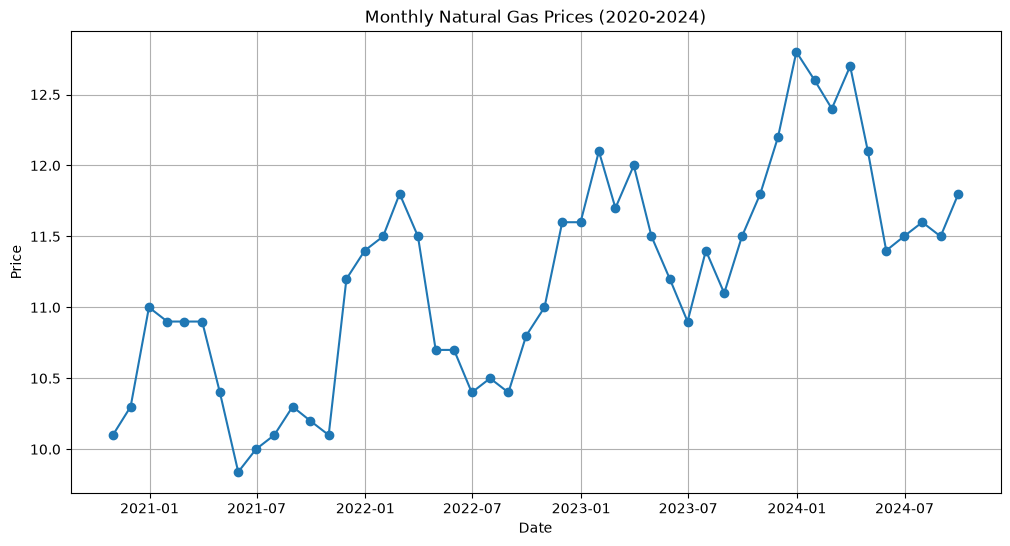

In [9]:
# Plotting the monthly gas prices
plt.figure(figsize=(12,6))

plt.plot(df["Dates"], df["Prices"], marker="o")

plt.title("Monthly Natural Gas Prices (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)

plt.show()

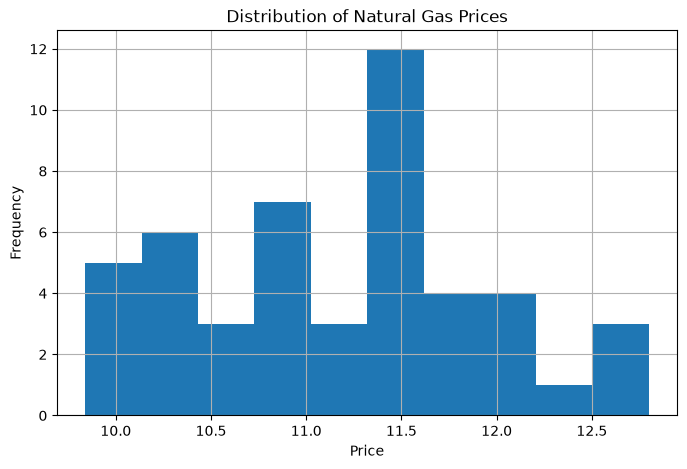

In [10]:
# Distribution of Natural gas prices

plt.figure(figsize=(8,5))

plt.hist(df["Prices"], bins=10)

plt.title("Distribution of Natural Gas Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [11]:
# Average price by month
df["Month"] = df["Dates"].dt.month
monthly_avg = df.groupby("Month")["Prices"].mean()

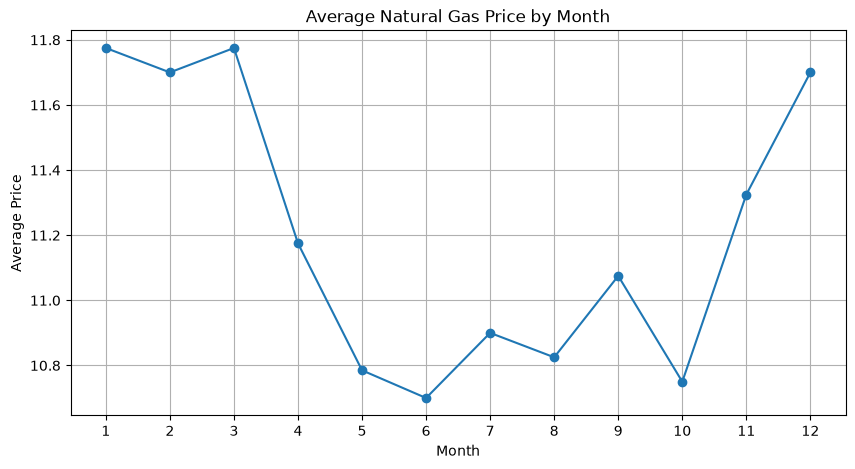

In [12]:
# Plotting average price by month
plt.figure(figsize=(10,5))

plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Average Natural Gas Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

In [13]:
# Set the dates as the DataFrame index
df = df.set_index("Dates")
df.head()

,Prices,Month
Dates,,
2020-10-31,10.1,10
2020-11-30,10.3,11
2020-12-31,11.0,12
2021-01-31,10.9,1
2021-02-28,10.9,2


In [14]:
# Create a daily date range
daily_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

In [15]:
# Reindex the DataFrame
df_daily = df.reindex(daily_index)

In [16]:
df_daily.head()

,Prices,Month
2020-10-31,10.1,10.0
2020-11-01,NaN,NaN
2020-11-02,NaN,NaN
2020-11-03,NaN,NaN
2020-11-04,NaN,NaN


In [17]:
# Interpolate the missing prices
df_daily["Prices"] = df_daily["Prices"].interpolate(method="linear")

In [18]:
df_daily = df_daily.drop(columns=["Month"])
df_daily.head()

,Prices
2020-10-31,10.100000
2020-11-01,10.106667
2020-11-02,10.113333
2020-11-03,10.120000
2020-11-04,10.126667


In [19]:
# Create daily estimated prices function
def estimate_price(date):
    date = pd.to_datetime(date)

    if date < df_daily.index.min() or date > df_daily.index.max():
        return "Date is outside the available historical data"
    
    return round(df_daily.loc[date, "Prices"], 2)

In [20]:
estimate_price("2023-07-15")

np.float64(11.14)

In [21]:
# Create future dates
future_dates = pd.date_range(
    start="2024-10-31",
    periods=12,
    freq="ME"
)

future_dates

DatetimeIndex(['2024-10-31', '2024-11-30', '2024-12-31', '2025-01-31',
               '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30'],
              dtype='datetime64[us]', freq='ME')

In [22]:
# Measure monthly price trends
monthly_change = df["Prices"].diff()
monthly_change

Dates
2020-10-31     NaN
2020-11-30    0.20
2020-12-31    0.70
2021-01-31   -0.10
2021-02-28    0.00
2021-03-31    0.00
2021-04-30   -0.50
2021-05-31   -0.56
2021-06-30    0.16
2021-07-31    0.10
2021-08-31    0.20
2021-09-30   -0.10
2021-10-31   -0.10
2021-11-30    1.10
2021-12-31    0.20
2022-01-31    0.10
2022-02-28    0.30
2022-03-31   -0.30
2022-04-30   -0.80
2022-05-31    0.00
2022-06-30   -0.30
2022-07-31    0.10
2022-08-31   -0.10
2022-09-30    0.40
2022-10-31    0.20
2022-11-30    0.60
2022-12-31    0.00
2023-01-31    0.50
2023-02-28   -0.40
2023-03-31    0.30
2023-04-30   -0.50
2023-05-31   -0.30
2023-06-30   -0.30
2023-07-31    0.50
2023-08-31   -0.30
2023-09-30    0.40
2023-10-31    0.30
2023-11-30    0.40
2023-12-31    0.60
2024-01-31   -0.20
2024-02-29   -0.20
2024-03-31    0.30
2024-04-30   -0.60
2024-05-31   -0.70
2024-06-30    0.10
2024-07-31    0.10
2024-08-31   -0.10
2024-09-30    0.30
Name: Prices, dtype: float64

In [23]:
# Compute average monthly increase
average_monthly_change = monthly_change.mean()

print(round(average_monthly_change, 4))

0.0362


In [24]:
# Seasonal effect on prices
df["Month"] = df.index.month
monthly_average = df.groupby("Month")["Prices"].mean()
overall_average = df["Prices"].mean()
seasonal_effect = monthly_average - overall_average

In [25]:
print(monthly_average)
print(round(overall_average, 2))
print(round(seasonal_effect, 2))

Month
1     11.775
2     11.700
3     11.775
4     11.175
5     10.785
6     10.700
7     10.900
8     10.825
9     11.075
10    10.750
11    11.325
12    11.700
Name: Prices, dtype: float64
11.21
Month
1     0.57
2     0.49
3     0.57
4    -0.03
5    -0.42
6    -0.51
7    -0.31
8    -0.38
9    -0.13
10   -0.46
11    0.12
12    0.49
Name: Prices, dtype: float64


In [26]:
# Forecast with Trend and Seasonality
forecast_prices = []

current_price = df["Prices"].iloc[-1]

for i, future_date in enumerate(future_dates, start=1):
    # Trend component
    trend = average_monthly_change * i

    # Seasonal component
    month = future_date.month
    season = seasonal_effect.loc[month]

    # Forecast
    forecast = current_price + trend + season

    forecast_prices.append(round(forecast, 2))

In [27]:
# Create forecast DataFrame
forecast_df = pd.DataFrame({
    "Dates": future_dates,
    "Forecast_Price": forecast_prices
})

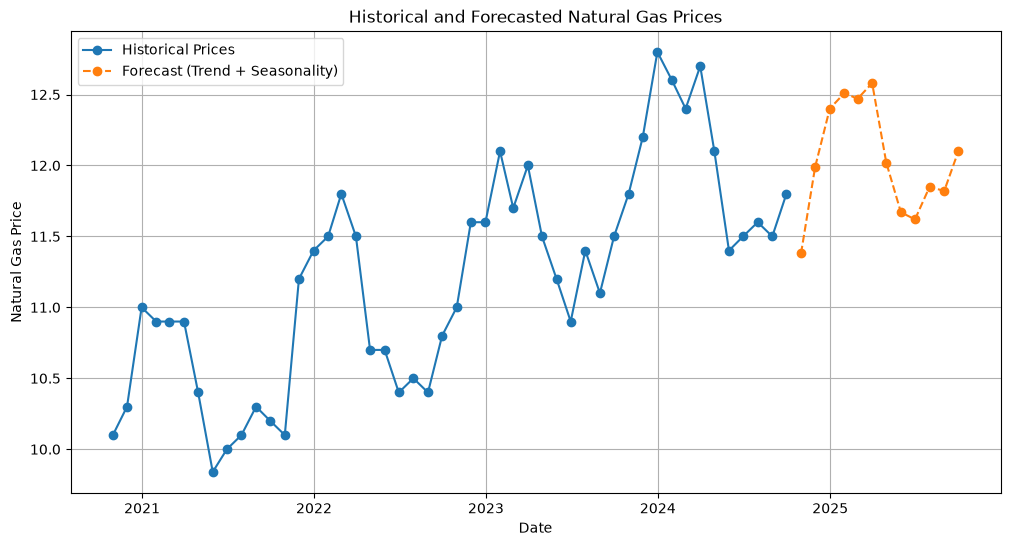

In [28]:
# Plot historical and forecast prices
plt.figure(figsize=(12,6))

# Historical prices
plt.plot(df.index, df["Prices"],
         label="Historical Prices",
         marker="o")

# Forecast prices
plt.plot(forecast_df["Dates"],
         forecast_df["Forecast_Price"],
         label="Forecast (Trend + Seasonality)",
         linestyle="--",
         marker="o")

plt.title("Historical and Forecasted Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
# Historical and future estimated daily prices 
def estimate_price(date):
    date = pd.to_datetime(date)

    # Historical period
    if date in df_daily.index:
        return round(df_daily.loc[date, "Prices"], 2)

    # Forecast period
    forecast_dates = forecast_df["Dates"].tolist()

    if date in forecast_dates:
        return round(
            forecast_df.loc[
                forecast_df["Dates"] == date,
                "Forecast_Price"
            ].values[0],
            2
        )

    return "Date is outside the supported range."

In [30]:
estimate_price("2024-06-15")  # Historical

np.float64(11.45)

In [31]:
estimate_price("2024-03-31")   # Forecast

np.float64(12.7)

In [32]:
forecast_df.head()

,Dates,Forecast_Price
0,2024-10-31,11.38
1,2024-11-30,11.99
2,2024-12-31,12.40
3,2025-01-31,12.51
4,2025-02-28,12.47


In [33]:
forecast_df.columns

Index(['Dates', 'Forecast_Price'], dtype='str')

In [34]:
# Daily forecast index
forecast_daily_index = pd.date_range(
    start=forecast_df.index.min(),
    end=forecast_df.index.max(),
    freq="D"
)

In [35]:
# Reindex the forecast DataFrame
forecast_daily = forecast_df.reindex(forecast_daily_index)

In [36]:
forecast_daily.head(10)

,Dates,Forecast_Price
1970-01-01,NaT,NaN


In [37]:
# Interpolate the daily prices
forecast_daily["Forecast_Price"] = (
    forecast_daily["Forecast_Price"].interpolate(method="linear")
)

In [38]:
forecast_daily.head(10)

,Dates,Forecast_Price
1970-01-01,NaT,NaN


In [39]:
# Combine historical and forecast data
forecast_daily = forecast_daily.rename(columns={"Forecast_Price": "Prices"})

In [40]:
# Combine and sort them by date
full_prices = pd.concat([df_daily, forecast_daily])
full_prices = full_prices.sort_index()

In [41]:
full_prices.head()

,Prices,Dates
1970-01-01,NaN,NaT
2020-10-31,10.100000,NaT
2020-11-01,10.106667,NaT
2020-11-02,10.113333,NaT
2020-11-03,10.120000,NaT


In [42]:
full_prices.tail()

,Prices,Dates
2024-09-26,11.76,NaT
2024-09-27,11.77,NaT
2024-09-28,11.78,NaT
2024-09-29,11.79,NaT
2024-09-30,11.80,NaT


In [43]:
# Final price estimate function
def estimate_price(date):
    date = pd.to_datetime(date)

    if date < full_prices.index.min() or date > full_prices.index.max():
        return "Date is outside the supported range."
    return round(full_prices.loc[date, "Prices"], 2)

In [44]:
estimate_price("2021-06-15")    # Historical

np.float64(9.92)

In [45]:
estimate_price("2025-03-15")     # Forecast

'Date is outside the supported range.'

## Conclusion
In this notebook, historical natural gas prices data was analyzed and prepared for forecasting. The monthly time series was cleaned, converted to datetime index and explored to identify seasonal patterns and overall price trends. A forecasting model was then developed to estimate future monthly gas prices and linear interpolation was used to generate daily estimated prices.

The resulting forecast provides a continuous series of historical and projected natural gas prices that can be used for downstream applications. This forecast serves as the foundation for the next task, where the estimated prices are used to value natural gas storage contracts under different market scenarios.